<a href="https://colab.research.google.com/github/Pranav5255/TE-ASSIGNMENTS/blob/DSBDL/A4/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment-4: Data Visualisation-I

## Objective

The objective of this assignment is to:

1. Explore the Titanic passenger dataset.

2. Visualize ticket fare distribution using Seaborn.

3. Identify survival patterns based on gender, passenger class, age, fare, and family size.

4. Perform meaningful exploratory data analysis (EDA) using visualizations.

## Dataset Description

- Dataset: `titanic_data.csv`

- Rows: 891 passengers

- Features include:
  - `Survived` (0 = No, 1 = Yes)

  - `Pclass` (Passenger Class)

  - `Sex`

  - `Age`

  - `Fare`

  - `Embarked`
  - `SibSp`, `Parch`

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Step 2: Load the Dataset (CSV)

In [2]:
df = pd.read_csv("titanic_data.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 3: Basic Dataset Information

In [3]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Step 4: Data Cleaning
### Handling Missing Values

- Age → filled using median

- Embarked → filled using mode

In [15]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


## Survival Count

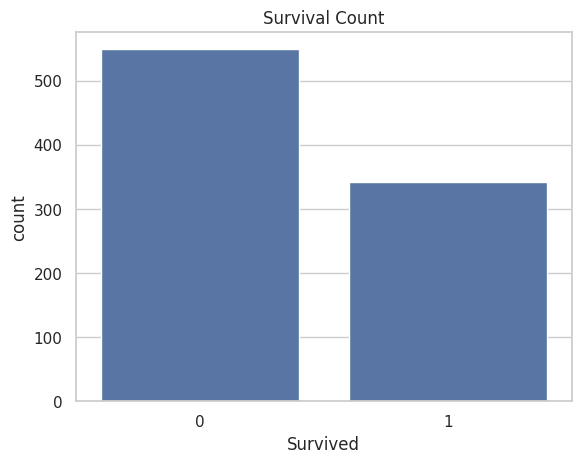

In [5]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()


## Survival by Gender

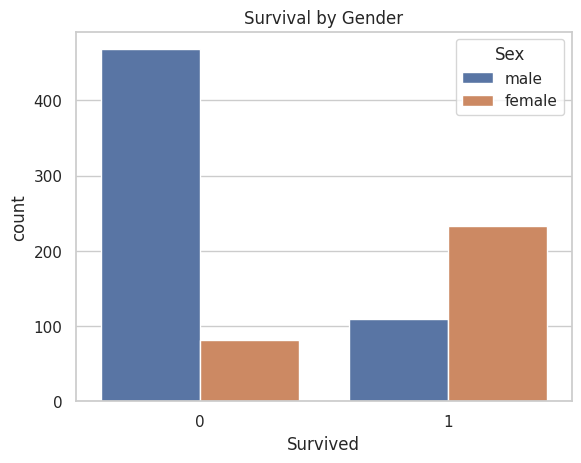

In [6]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival by Gender")
plt.show()

## Survival by Passenger Class

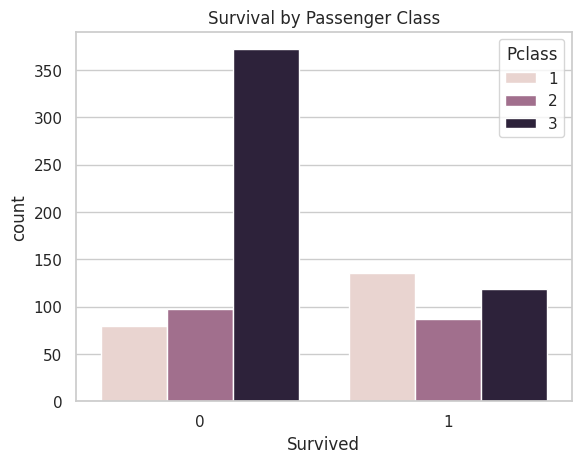

In [7]:
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title("Survival by Passenger Class")
plt.show()


## Histogram of Ticket Fare Distribution

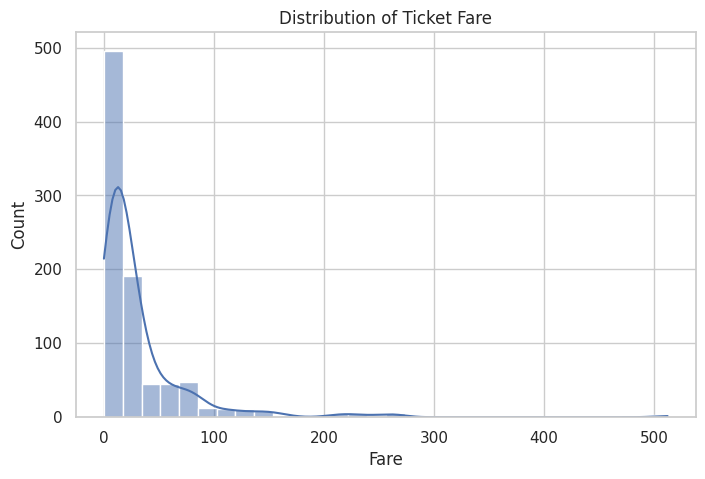

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Distribution of Ticket Fare")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()


## Gender-wise Survival in Each Passenger Class

In [9]:
gender_class_survival = df.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()
gender_class_survival


,Pclass,Sex,Survived
0,1,female,0.968085
1,1,male,0.368852
2,2,female,0.921053
3,2,male,0.157407
4,3,female,0.500000
5,3,male,0.135447


### Visualization

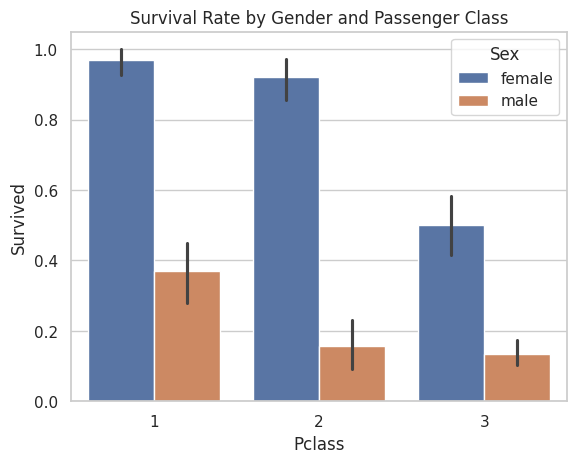

In [10]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.title("Survival Rate by Gender and Passenger Class")
plt.show()


### Observation

- Females had higher survival rates in all classes

- First-class females had the highest survival probability

- Third-class males had the lowest survival probability

## Survival Rate by Passenger Class

In [11]:
df.groupby('Pclass')['Survived'].mean()


,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


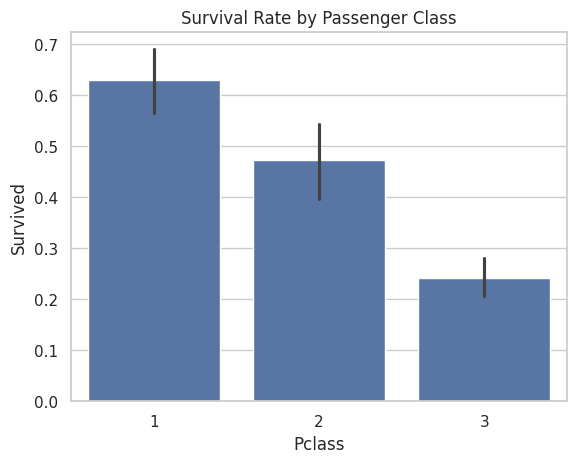

In [12]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()


## Age vs Survival

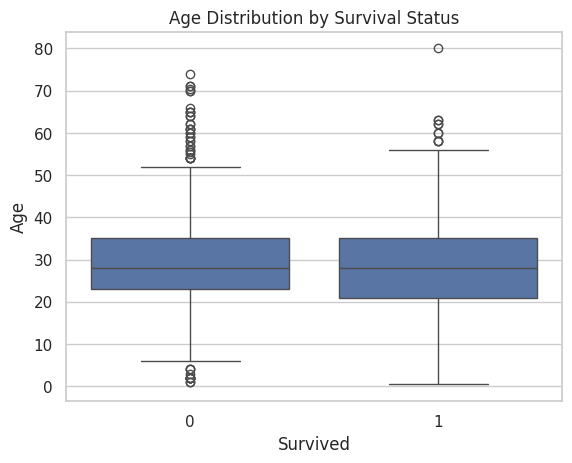

In [13]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age Distribution by Survival Status")
plt.show()


## Embarkation Port vs Survival

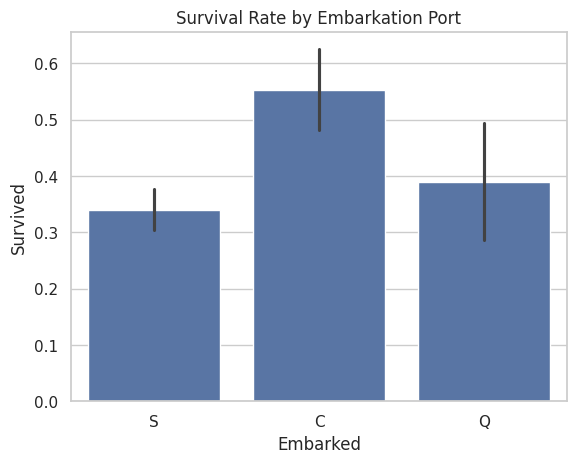

In [14]:
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title("Survival Rate by Embarkation Port")
plt.show()


## Final Conclusion

- Gender was the most influential factor in survival.

- Passenger class and fare strongly affected survival chances.

- Women and children were prioritized during evacuation.

- Passengers from higher classes and higher fares had better access to lifeboats.

- Small families survived better than solo or very large groups.